In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

DATA_PATH = "/content/drive/MyDrive/Assignment"

df = pd.read_csv(f"{DATA_PATH}/dataset.csv")

df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [3]:
# =====================================================
# IMPORT LIBRARIES
# =====================================================

# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

import joblib


In [4]:
missing_values = df.isnull().sum()
print(missing_values)

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64


In [5]:
duplicate_rows = df.duplicated()

print("Duplicates:", duplicate_rows.sum())

df = df.drop_duplicates()

print("New Shape:", df.shape)

Duplicates: 0
New Shape: (3333, 20)


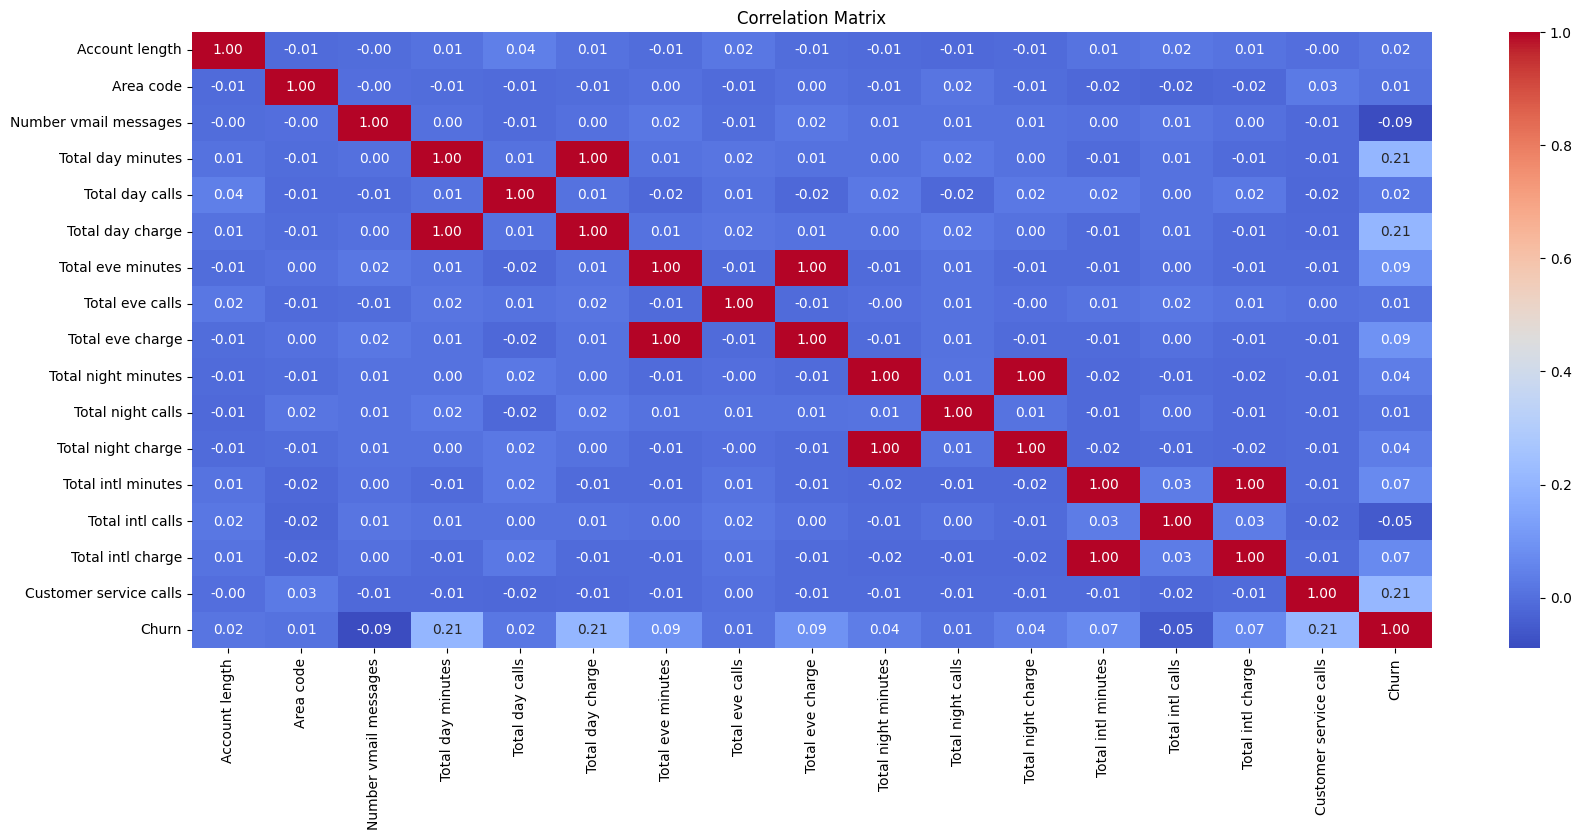

In [6]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(20,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

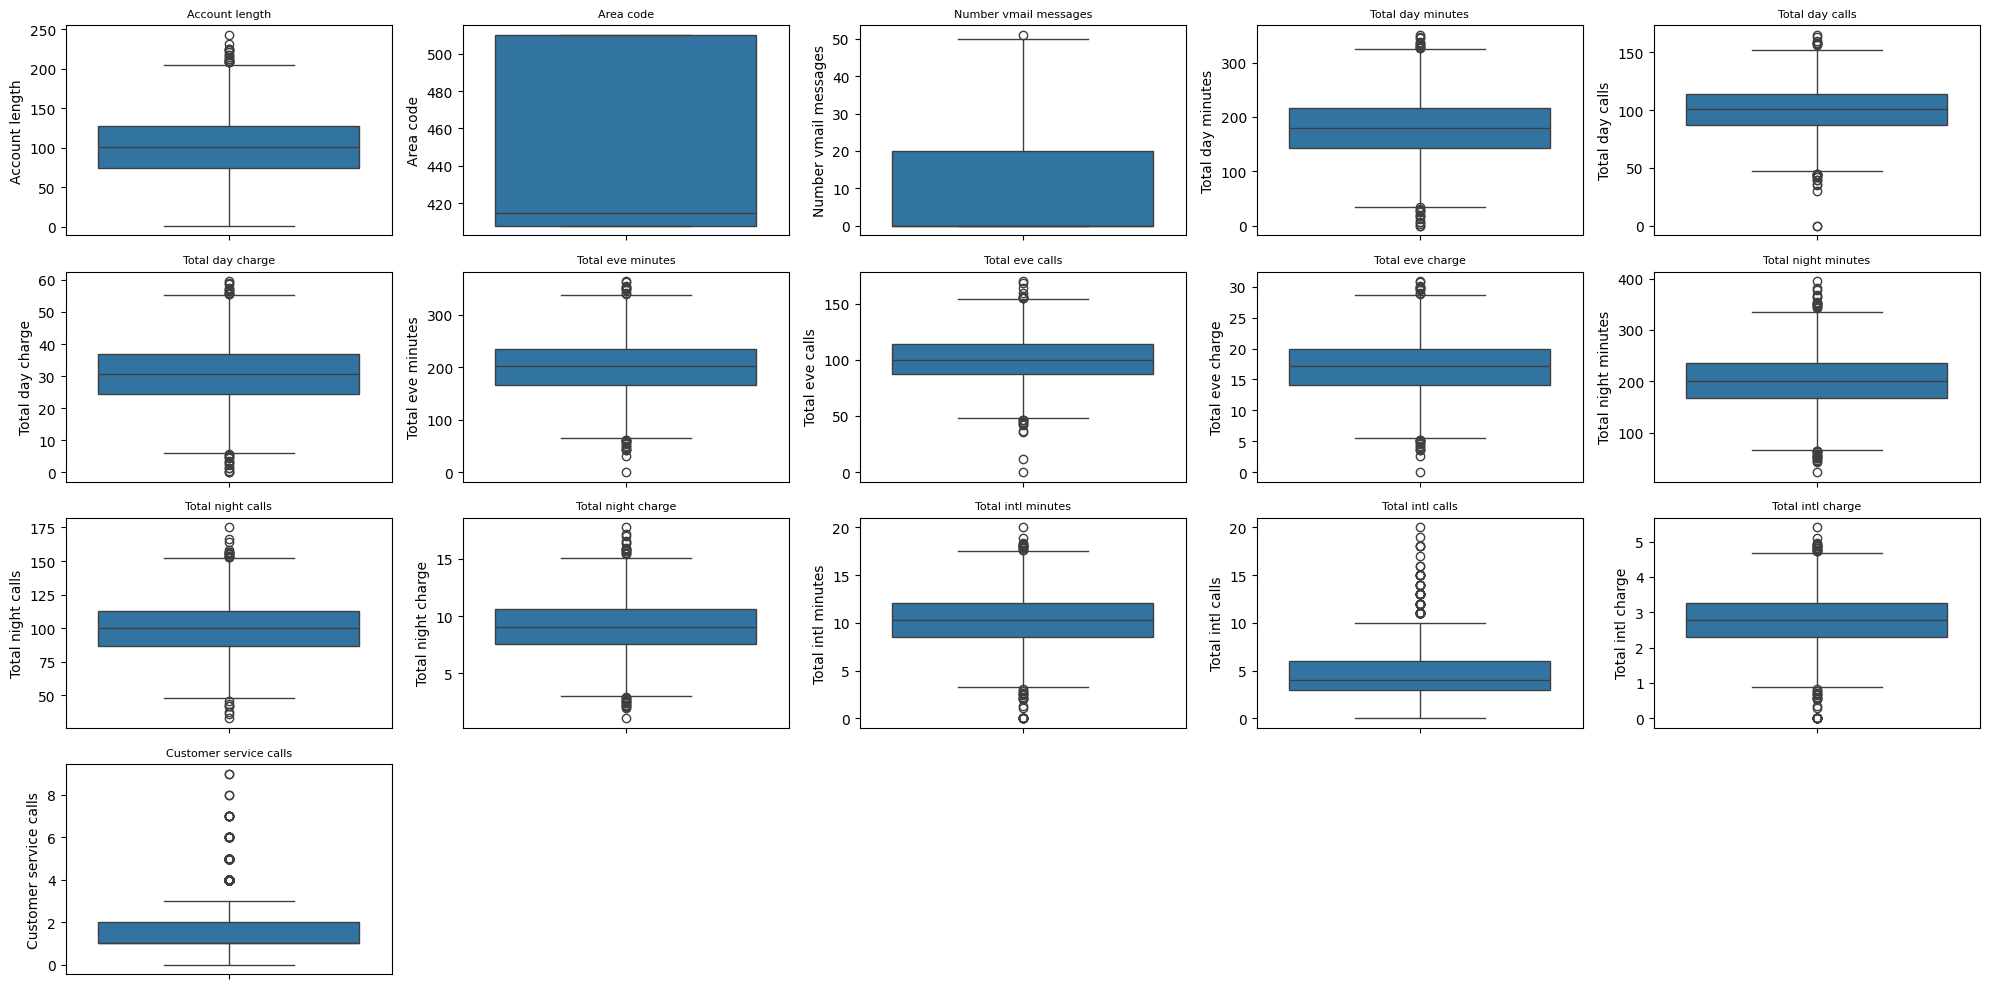

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(20,10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 5, i)   # 4 rows × 5 columns
    sns.boxplot(y=df[col])
    plt.title(col, fontsize=8)

plt.tight_layout()
plt.show()

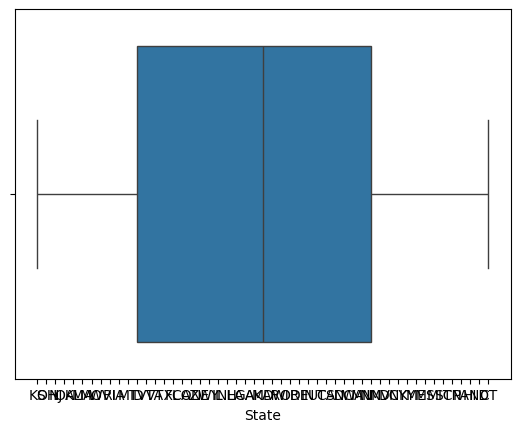

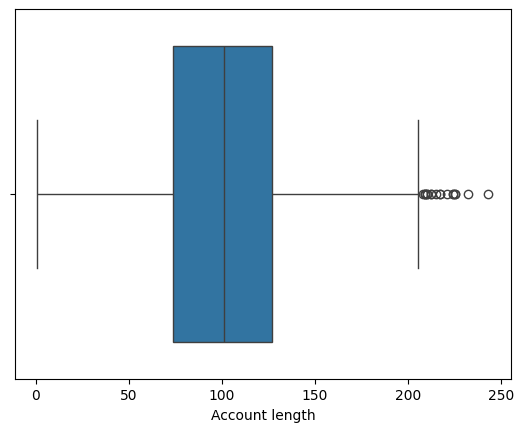

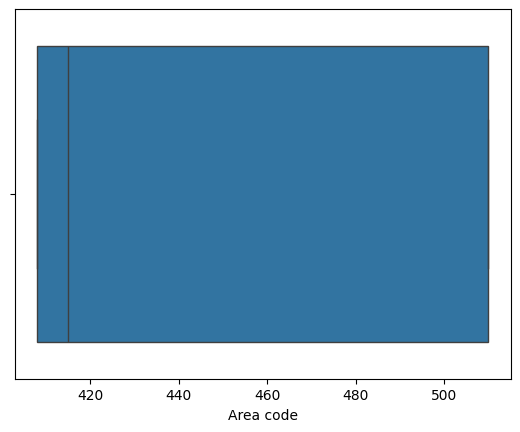

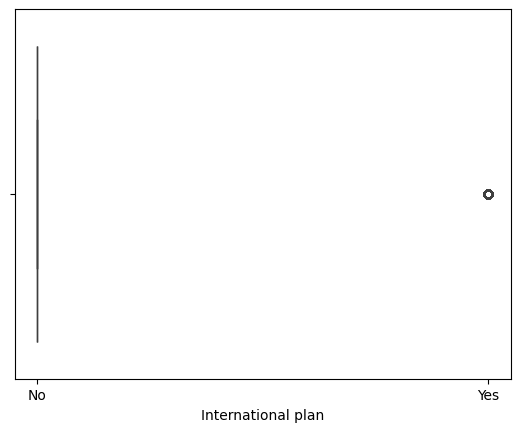

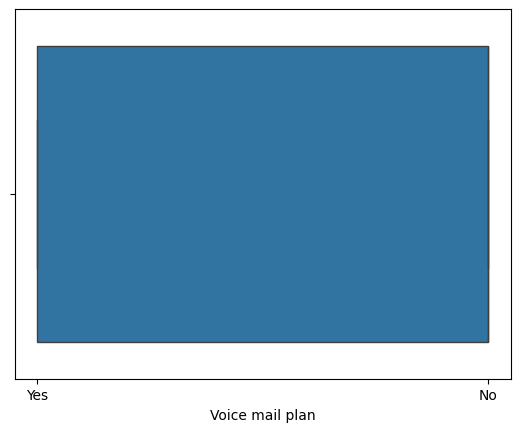

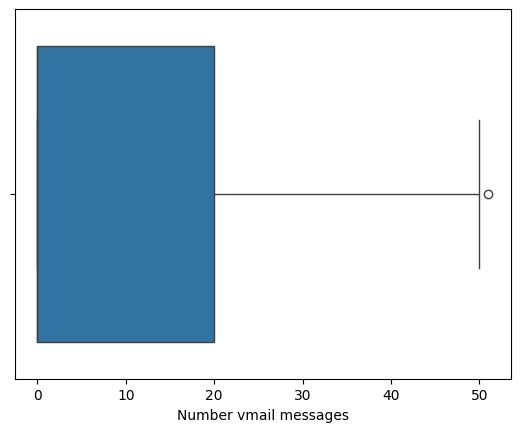

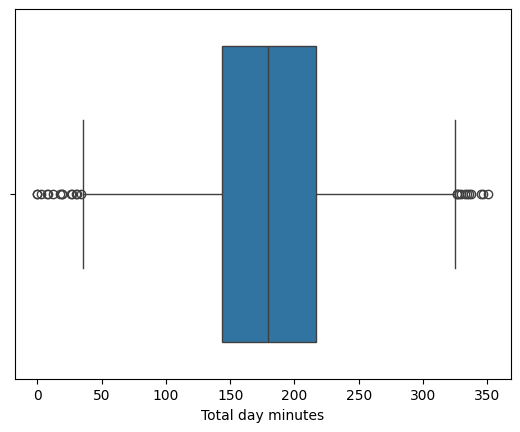

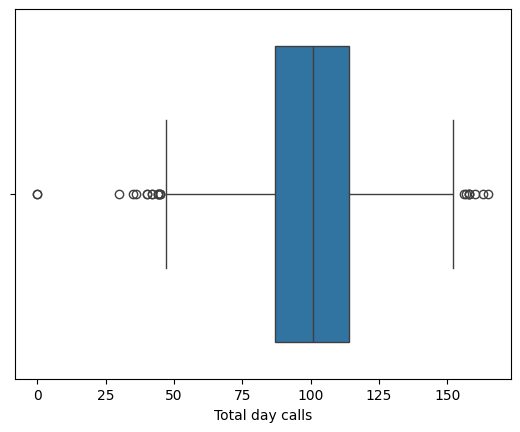

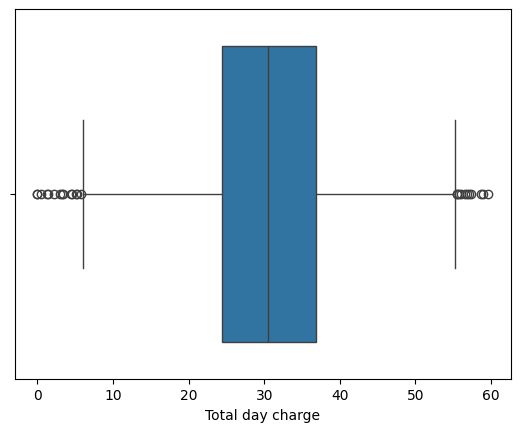

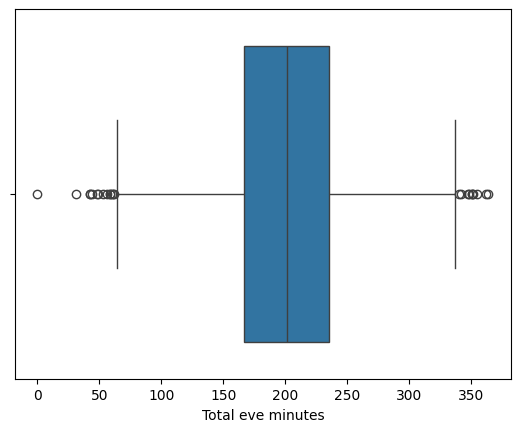

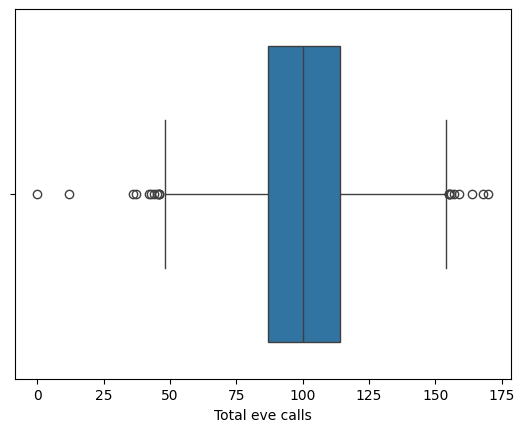

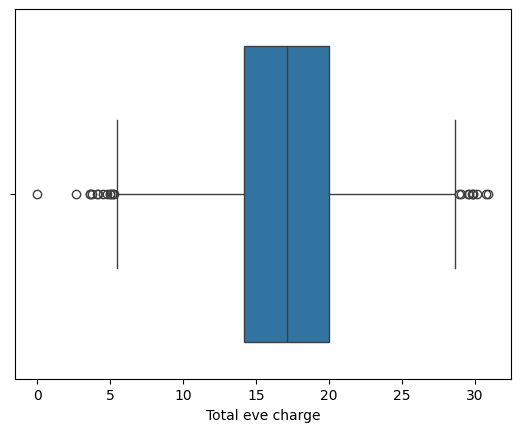

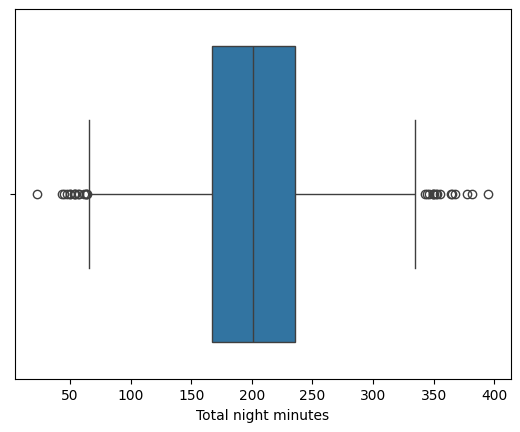

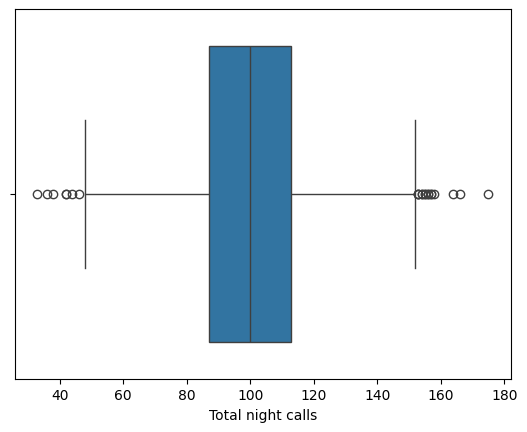

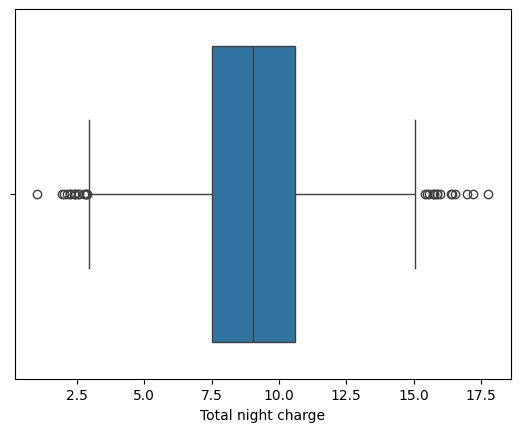

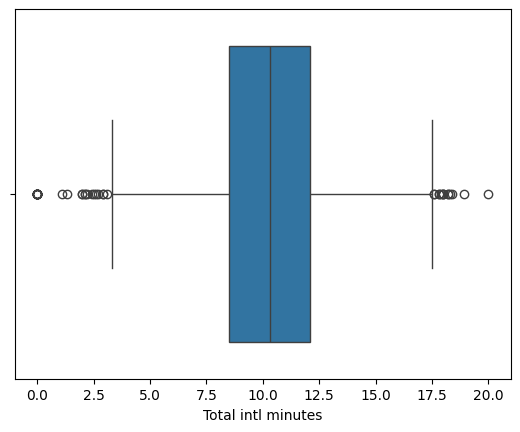

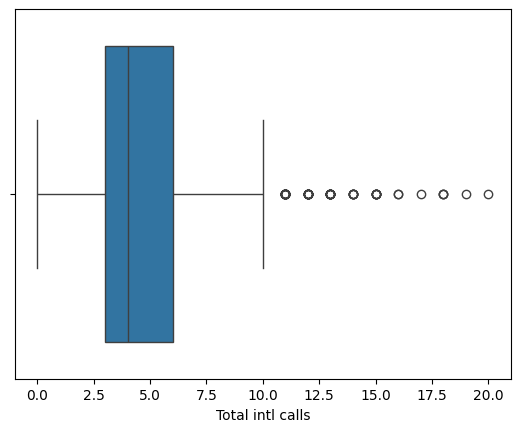

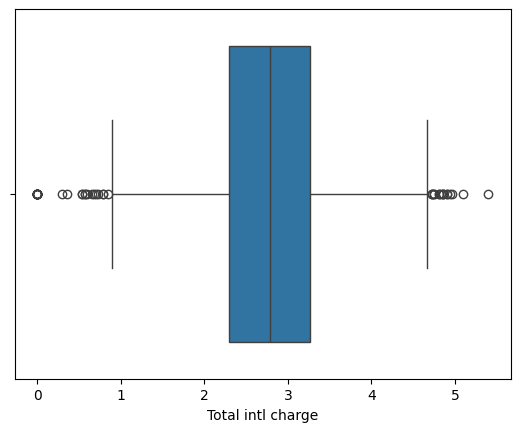

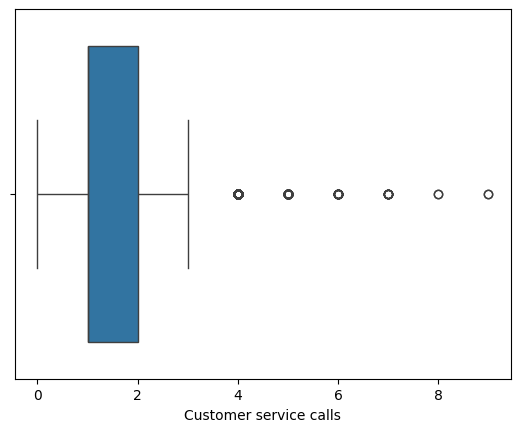

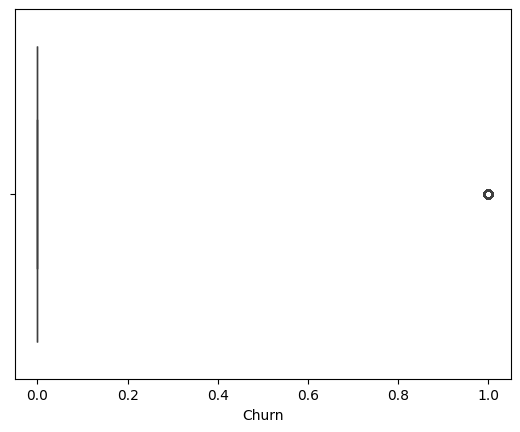

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in df.columns:
    sns.boxplot(x=df[col])
    plt.show()

In [8]:
df.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


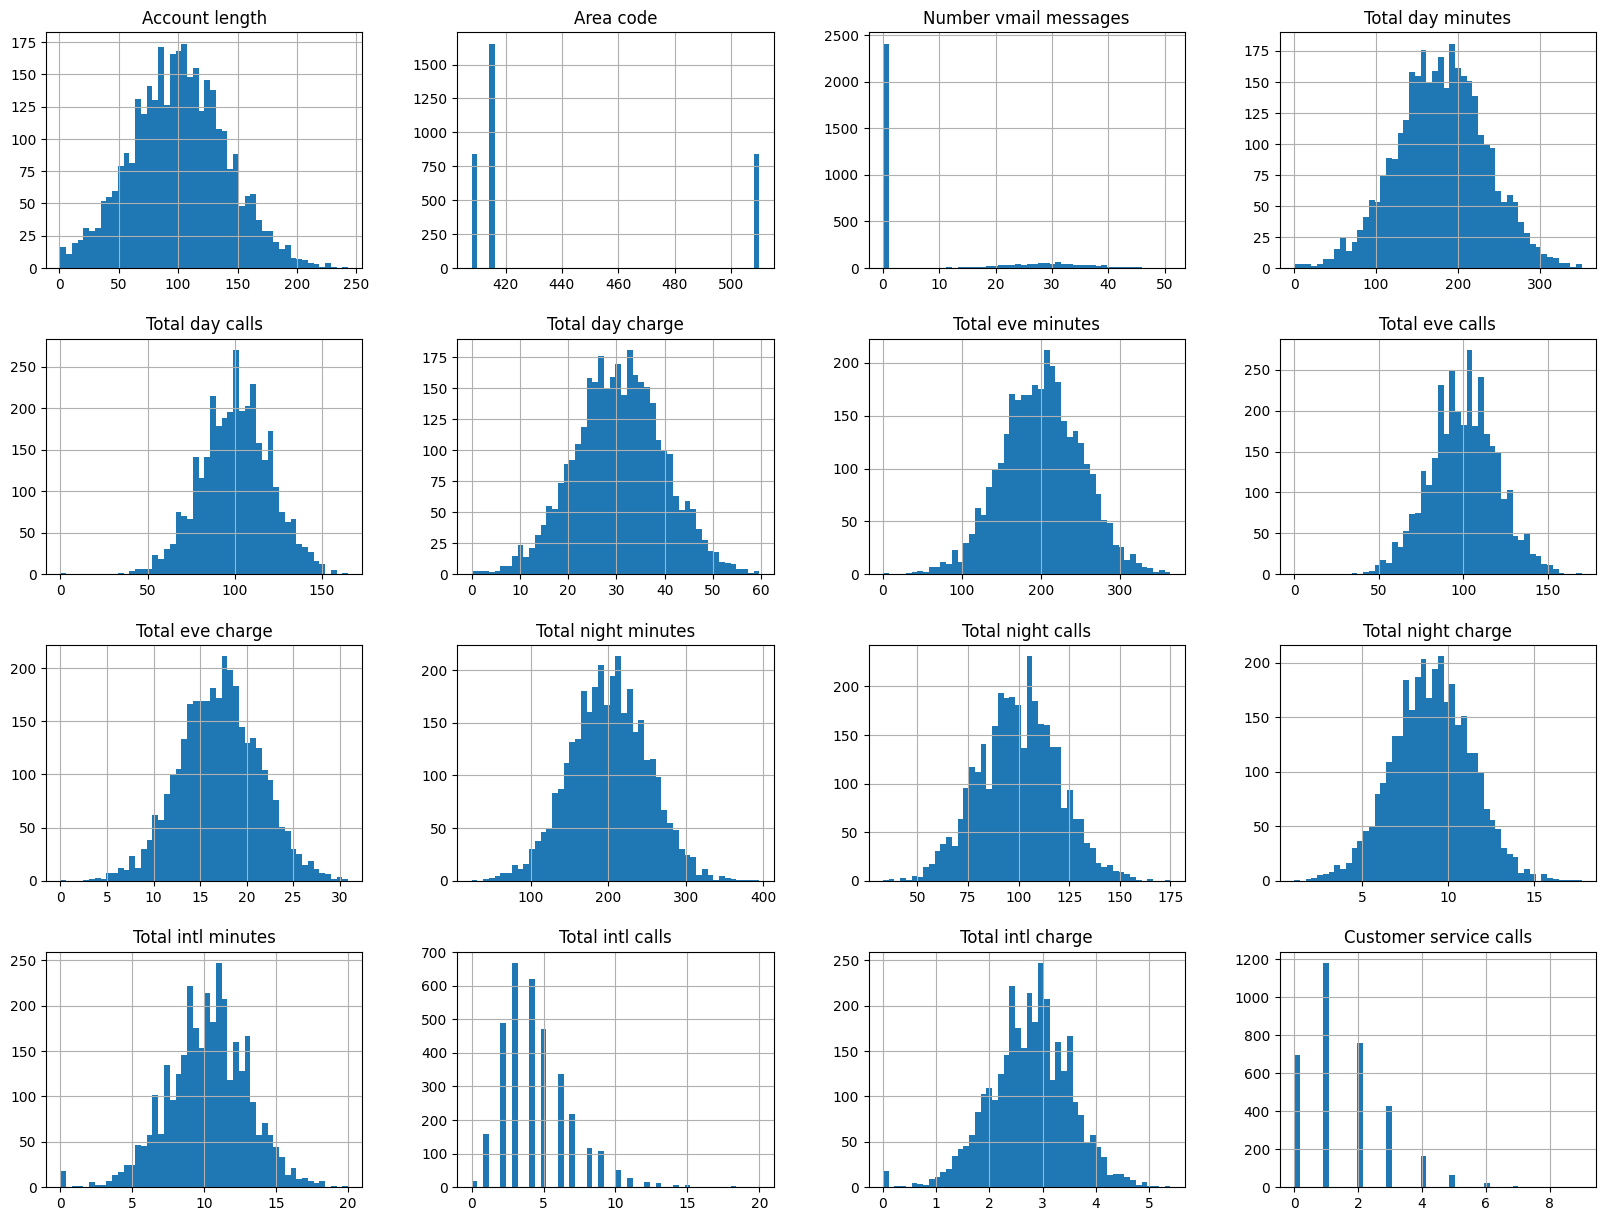

In [9]:
df.hist(bins=50, figsize=(20,15))
plt.show()

In [10]:
duplicate_rows = df.duplicated()
print(f"Number of duplicate rows: {duplicate_rows.sum()}")

df = df.drop_duplicates()
print("Shape of Dataframe After Removing Duplicates:", df.shape)

Number of duplicate rows: 0
Shape of Dataframe After Removing Duplicates: (3333, 20)


In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_cols = ['State', 'International plan', 'Voice mail plan', 'Churn']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [12]:
print(df['State'].unique())
print(df['International plan'].unique())
print(df['Voice mail plan'].unique())
print(df['Churn'].unique())

[16 35 31 36  1 19 24 49 39 12 26 13 46 45 43  9  5  3 29 50 14 30 18 10
  0 20  2 48 37  8 15 44  4 41 27 47 23 32 33  7 34 17 21 25 22 40 42 38
 11 28  6]
[0 1]
[1 0]
[0 1]


In [13]:
X = df.drop(['Churn'], axis=1)
y = df['Churn']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [15]:
models = {'Decision Tree' : DecisionTreeClassifier(),
          'Random Forest' : RandomForestClassifier(),
          'SVC' : SVC(),
          'Naive Bayes' : GaussianNB(),
          'KNN' : KNeighborsClassifier()
}

Decision Tree Accuracy: 0.9160
Decision Tree Precision: 0.9147
Decision Tree Recall: 0.9160
Decision Tree F1-score: 0.9153
----------------------------------------------------------------


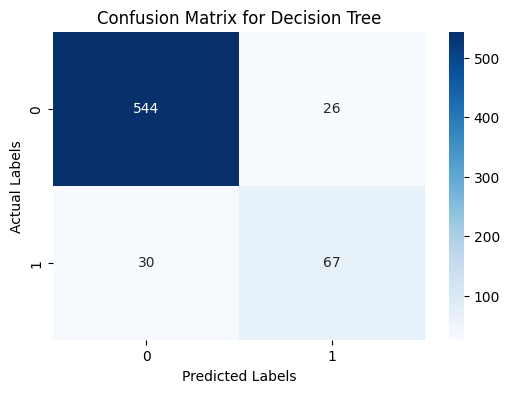

----------------------------------------------------------------
Random Forest Accuracy: 0.9490
Random Forest Precision: 0.9501
Random Forest Recall: 0.9490
Random Forest F1-score: 0.9450
----------------------------------------------------------------


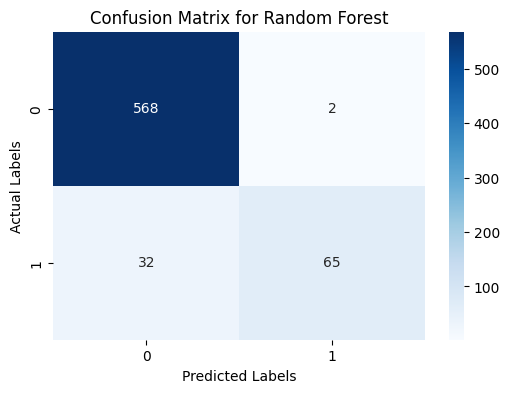

----------------------------------------------------------------
SVC Accuracy: 0.8546
SVC Precision: 0.7303
SVC Recall: 0.8546
SVC F1-score: 0.7876
----------------------------------------------------------------


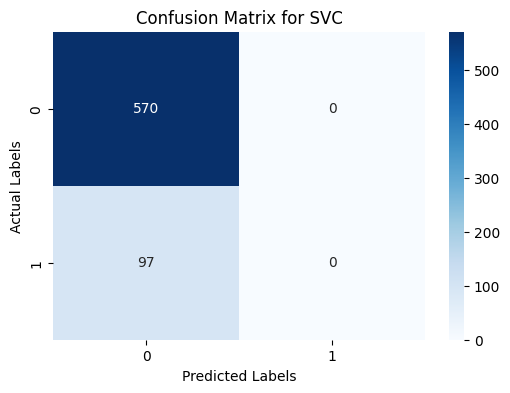

----------------------------------------------------------------
Naive Bayes Accuracy: 0.8606
Naive Bayes Precision: 0.8600
Naive Bayes Recall: 0.8606
Naive Bayes F1-score: 0.8603
----------------------------------------------------------------


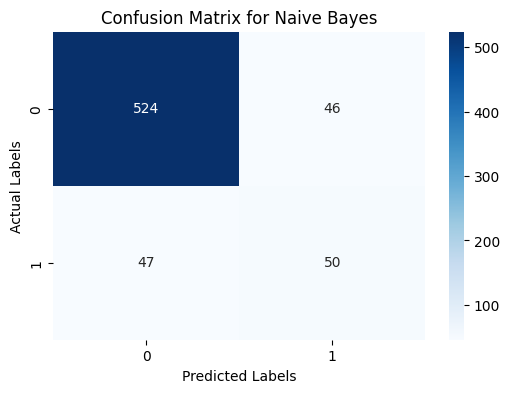

----------------------------------------------------------------
KNN Accuracy: 0.8561
KNN Precision: 0.8234
KNN Recall: 0.8561
KNN F1-score: 0.8274
----------------------------------------------------------------


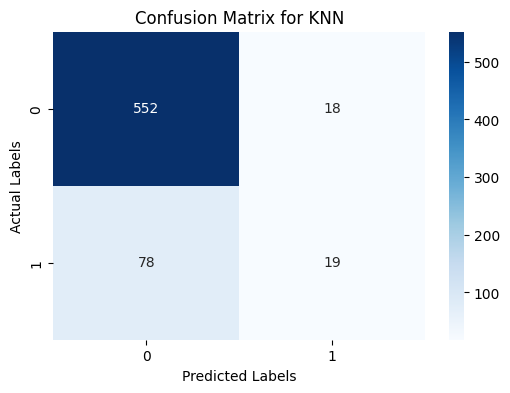

----------------------------------------------------------------


In [16]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"{name} Accuracy: {accuracy:.4f}")
    print(f"{name} Precision: {precision:.4f}")
    print(f"{name} Recall: {recall:.4f}")
    print(f"{name} F1-score: {f1:.4f}")
    print("-"*64)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix for {name}")
    plt.xlabel('Predicted Labels')
    plt.ylabel('Actual Labels')
    plt.show()
    print("-"*64)

In [17]:
chosen_model_name = "Random Forest" # Change this to the desired model name
chosen_model = models[chosen_model_name]

y_pred = chosen_model.predict(X_test) # Use the trained model to make predictions

# Evaluate the accuracy of the chosen model for oveall
accuracy = accuracy_score(y_test, y_pred) # (Actual class, Predicted class)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"{chosen_model_name} Accuracy: {accuracy:.4f}")
print(f"{chosen_model_name} Precision: {precision:.4f}")
print(f"{chosen_model_name} Recall: {recall:.4f}")
print(f"{chosen_model_name} F1-Score: {f1:.4f}")

Random Forest Accuracy: 0.9490
Random Forest Precision: 0.9501
Random Forest Recall: 0.9490
Random Forest F1-Score: 0.9450


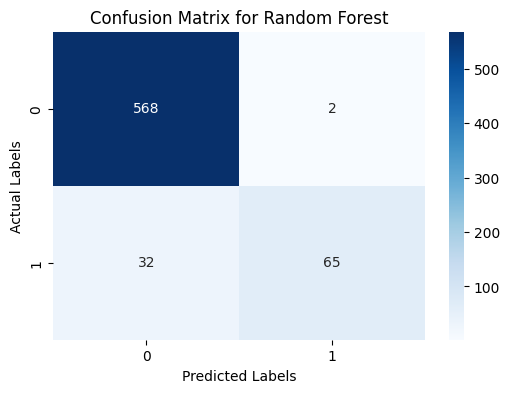

In [18]:
# Compute the confusion matrix for multi-class classification
cm = confusion_matrix(y_test, y_pred) # (Actual class, Predicted class)
# Plot the confusion matrix as a heatmap for multi-class
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix for {chosen_model_name}")
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.show()

In [20]:
import joblib
chosen_model = models['Random Forest']
model_filepath = "/content/drive/MyDrive/Assignment/model.pkl"
joblib.dump(chosen_model, model_filepath)

print(f"{model_filepath}")

/content/drive/MyDrive/Assignment/model.pkl
